In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
sim = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard",
    pct_pre_approved=0,
    pct_custom=1,
    pct_self_cert=0,
    pct_like_for_like=0
)

# Get and display statistics
stats = sim.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :    0 ( 0.00%)
  CUSTOM_NON_LIKE               : 6410 (100.00%)
  PRE_APPROVED_LIKE             :    0 ( 0.00%)
  PRE_APPROVED_NON_LIKE         :    0 ( 0.00%)
  SELF_CERT_LIKE                :    0 ( 0.00%)
  SELF_CERT_NON_LIKE            :    0 ( 0.00%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     483.54 days
  Median:   482.64 days
  Std Dev:  200.91 days
  Min:       93.38 days
  Max:     1300.78 days

--------------------------------------------------------------------------------
PROCESSING T

In [2]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 499 (CUSTOM_NON_LIKE): 93.38 days total, 1 re-checks
  Permit 284 (CUSTOM_NON_LIKE): 93.67 days total, 2 re-checks
  Permit 662 (CUSTOM_NON_LIKE): 95.07 days total, 0 re-checks
  Permit 440 (CUSTOM_NON_LIKE): 97.70 days total, 1 re-checks
  Permit 960 (CUSTOM_NON_LIKE): 109.28 days total, 1 re-checks


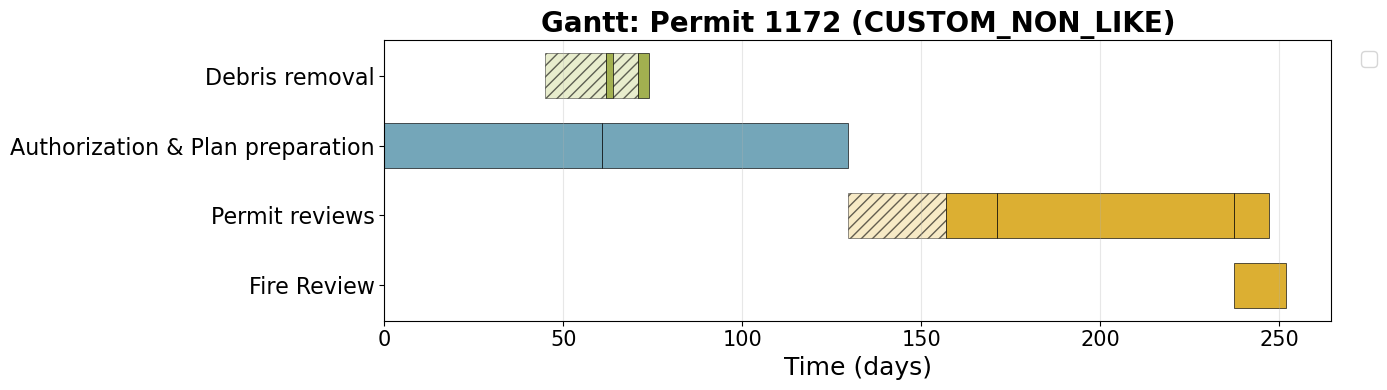

In [3]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_one_random_permit_segment
import matplotlib.pyplot as plt

fig, ax = plot_gantt_one_random_permit_segment(
    sim.completed_permits,
    segment_value=4,
    random_seed=37,
    figsize=(14, 4),
)
if fig:
    plt.show()

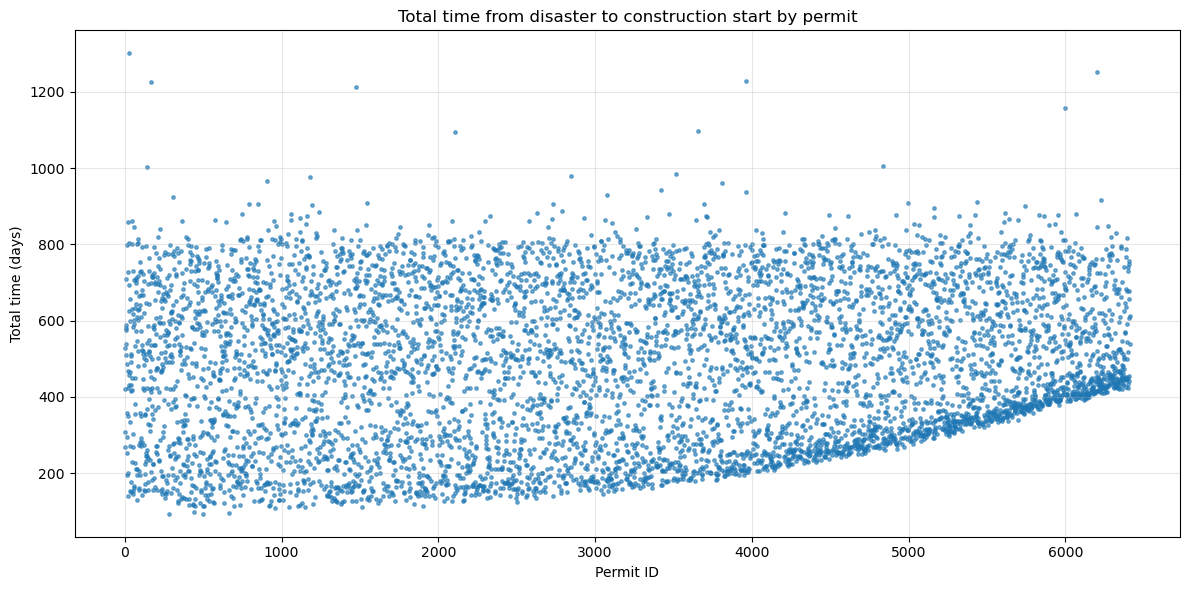

In [4]:
# Plot permit number (ID) vs total time to construction
import matplotlib.pyplot as plt

permit_ids = []
total_times = []

for p in sim.completed_permits:
    if p.ready_for_construction is not None and p.created_at is not None:
        permit_ids.append(p.permit_id)
        total_times.append(p.ready_for_construction - p.created_at)

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, s=6, alpha=0.6)
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

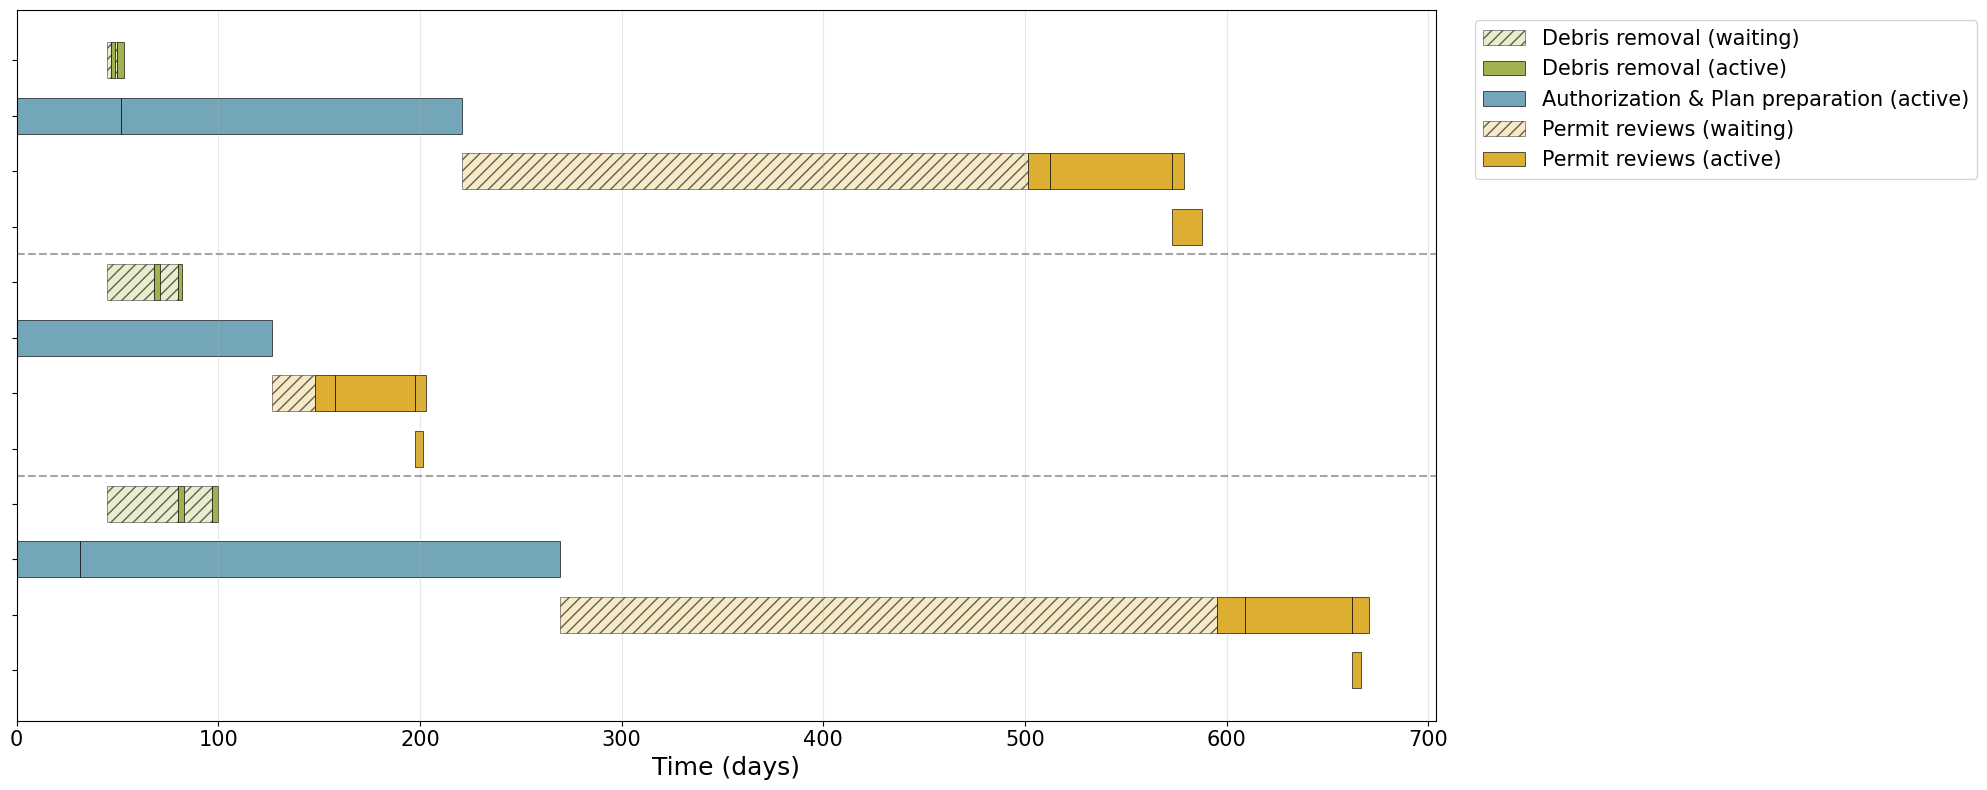

In [5]:
# Gantt chart for 3 random permits
from visualize_permits import plot_gantt_three_random_permits
import matplotlib.pyplot as plt

fig, ax = plot_gantt_three_random_permits(
    sim.completed_permits,
    random_seed=42,
    figsize=(20, 8),
)
if fig:
    plt.show()

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Average Total Waiting vs Service Time by Process Step'}, xlabel='Process Step', ylabel='Average Time (days)'>)

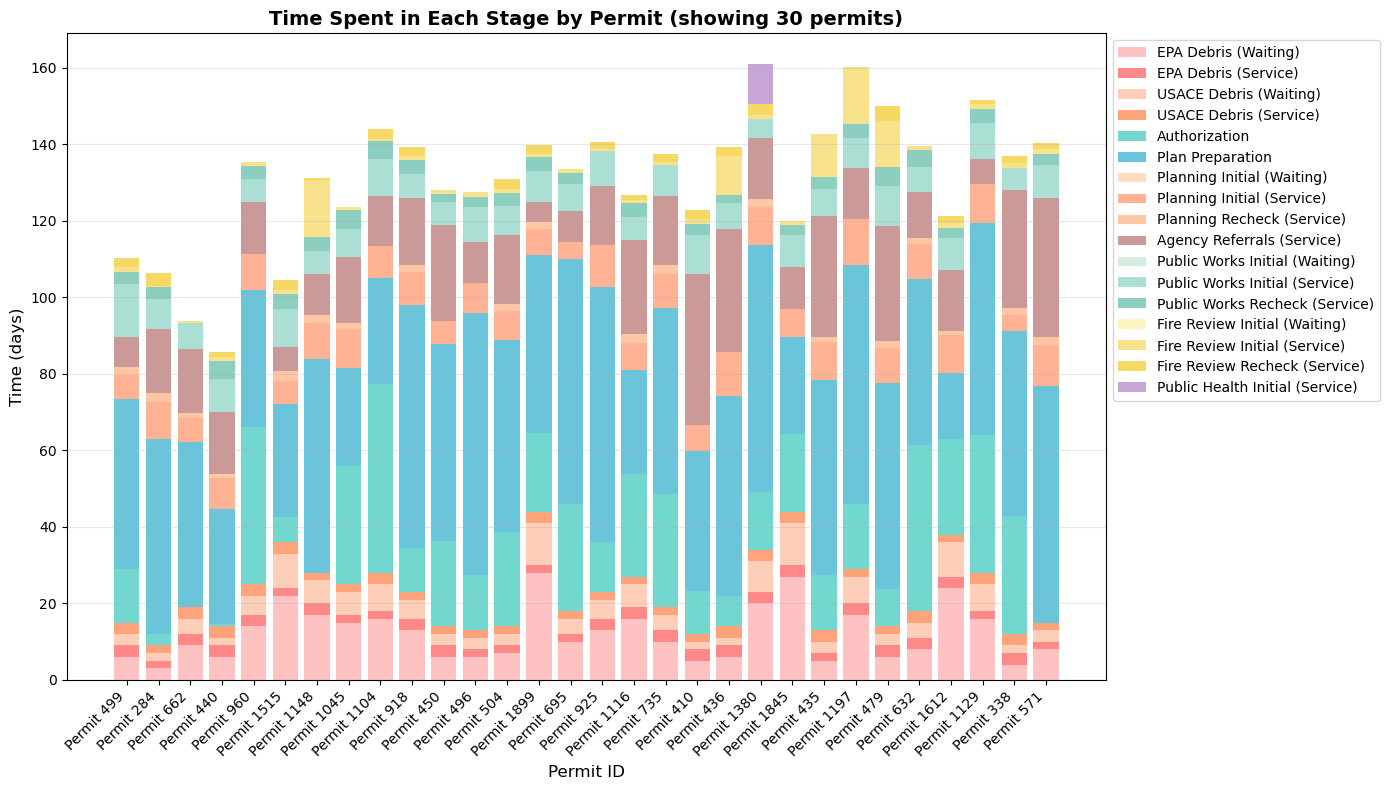

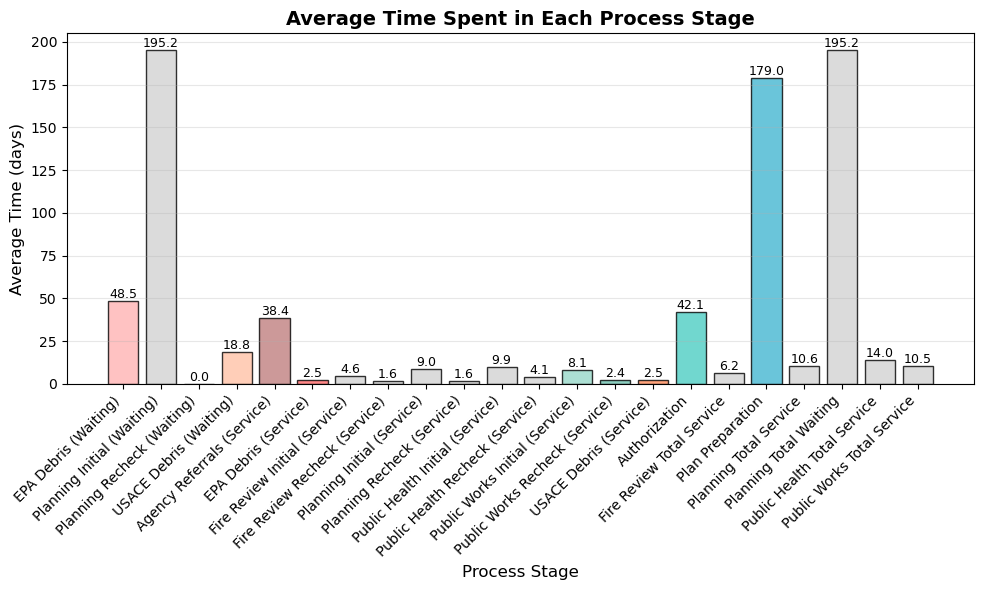

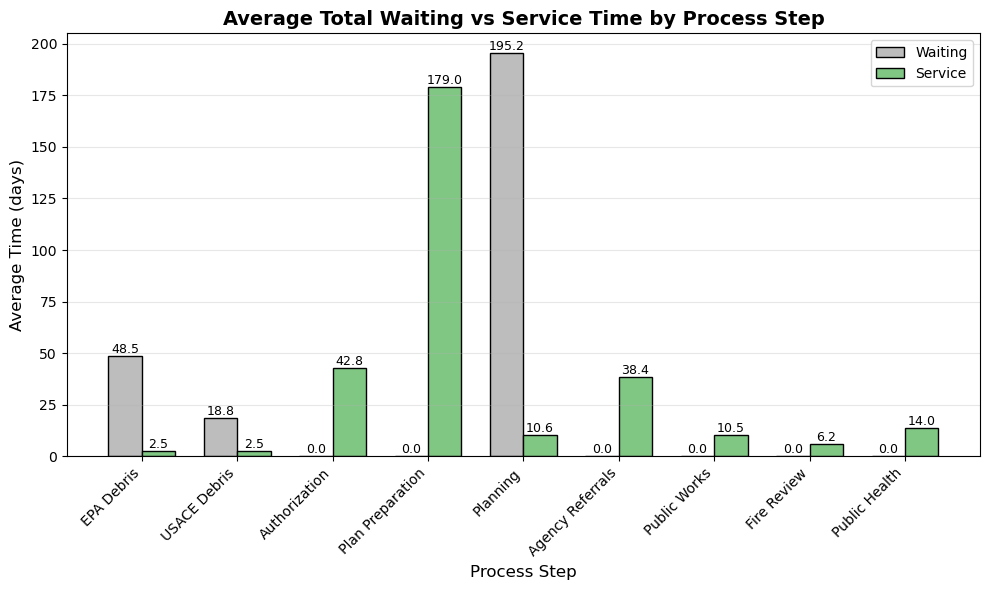

In [6]:
# Visualize the time each permit spends in each stage
from visualize_permits import plot_average_waiting_and_service_by_step, visualize_all, plot_stacked_bar_chart, plot_average_time_by_stage, plot_average_waiting_and_service_by_step


# Or create individual visualizations:
plot_stacked_bar_chart(sim.completed_permits, max_permits=30)  # Stacked bar chart
plot_average_time_by_stage(sim.completed_permits)  
plot_average_waiting_and_service_by_step(sim.completed_permits)            # Average time by stage            # Average time by stage
